In [1]:
# ===============================================================================
# CELL 1: REALISTIC HR COGNITIVE LOAD DATASET GENERATION & PREPROCESSING
# ===============================================================================

import numpy as np
import pandas as pd
import os
import random
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)

# Configuration
N = 10000
out_dir = '/content'
os.makedirs(out_dir, exist_ok=True)

print("="*80)
print("HR COGNITIVE LOAD DATASET GENERATION AND PREPROCESSING")
print("="*80)

# ==================== JOB TITLES (29 designations) ====================
job_titles = [
    "Software Engineer I", "Software Engineer II", "Senior Software Engineer", "Staff Engineer",
    "Engineering Manager", "Director of Engineering", "Product Manager", "Senior Product Manager",
    "Data Scientist I", "Data Scientist II", "Senior Data Scientist", "Machine Learning Engineer",
    "QA Engineer", "DevOps Engineer", "Site Reliability Engineer", "UX Designer", "Research Scientist",
    "Business Analyst", "Sales Executive", "Account Manager", "Customer Success Manager",
    "Marketing Manager", "Finance Analyst", "HR Associate", "Operations Manager", "C-Level Executive"
]

# Map job title -> department
dept_map = {
    "Software": "Engineering", "Engineer": "Engineering", "Engineering": "Engineering",
    "Data": "DataScience", "Machine": "DataScience", "QA": "Engineering", "DevOps": "Engineering",
    "Research": "R&D", "Business": "Finance", "Sales": "Sales", "Account": "Sales", "Customer": "CustomerSuccess",
    "Marketing": "Marketing", "Finance": "Finance", "HR": "HR", "Operations": "Operations", "C-Level": "Executive"
}

def title_to_dept(title):
    for k, v in dept_map.items():
        if k in title:
            return v
    return "Other"

# ==================== ROLE LEVELS & SALARIES ====================
levels = ['Junior', 'Mid', 'Senior', 'Lead', 'C-Level']
level_probs = [0.45, 0.30, 0.18, 0.05, 0.02]
level_salary_multipliers = {'Junior': 0.8, 'Mid': 1.0, 'Senior': 1.8, 'Lead': 3.5, 'C-Level': 6.0}
base_band = (300000, 900000)

def sample_salary(level, exp):
    mn = int(base_band[0] * level_salary_multipliers[level])
    med = int(base_band[1] * level_salary_multipliers[level])
    mx = int(med * 3.0)
    base = int(np.clip(np.random.triangular(mn, med, mx), mn, mx))
    exp_premium = int((exp - 3) * 4000)
    noise = int(np.random.normal(0, 15000))
    return max(150000, min(200000000, base + exp_premium + noise))

# ==================== EMPLOYEE PERSONAS (Individual Differences) ====================
personas = ['Resilient', 'Sensitive', 'Balanced', 'Workaholic', 'Struggling']
persona_probs = [0.15, 0.12, 0.50, 0.10, 0.13]
persona_stress_multiplier = {'Resilient': 0.65, 'Sensitive': 1.45, 'Balanced': 1.0, 'Workaholic': 1.2, 'Struggling': 1.8}
persona_performance_bias = {'Resilient': 0.3, 'Sensitive': -0.1, 'Balanced': 0.0, 'Workaholic': 0.2, 'Struggling': -0.4}
persona_capacity_multiplier = {'Resilient': 1.25, 'Sensitive': 0.85, 'Balanced': 1.0, 'Workaholic': 1.1, 'Struggling': 0.7}

# ==================== GENERATE BASE EMPLOYEE DATA ====================
employee_id = [f'EMP{200000+i}' for i in range(N)]
job_title_sampled = [random.choice(job_titles) for _ in range(N)]
department = [title_to_dept(t) for t in job_title_sampled]
role_level = np.random.choice(levels, size=N, p=level_probs)
employee_persona = np.random.choice(personas, size=N, p=persona_probs)

# Hire dates and tenure
start = datetime(2005, 1, 1)
end = datetime.now()
hire_dates = [start + timedelta(days=int(np.random.rand() * (end - start).days)) for _ in range(N)]
tenure_years = np.round([(datetime.now() - hd).days / 365.25 for hd in hire_dates], 2)
experience_years = np.clip(np.round(tenure_years + np.random.normal(2.5, 2.5, size=N)), tenure_years, 40)

# Salary
salaries = [sample_salary(lvl, exp) for lvl, exp in zip(role_level, experience_years)]

# ==================== PERFORMANCE HISTORY (with trends and noise) ====================
base_perf = np.random.choice([1, 2, 3, 4, 5], size=N, p=[0.04, 0.12, 0.50, 0.26, 0.08])
base_perf = np.clip(base_perf + [persona_performance_bias[p] for p in employee_persona], 1.0, 5.0)

perf_hist = []
for p in base_perf:
    h1 = np.clip(p + np.random.normal(0, 0.4), 1.0, 5.0)
    h2 = np.clip(h1 + np.random.normal(0, 0.3), 1.0, 5.0)
    h3 = np.clip(h2 + np.random.normal(0, 0.25), 1.0, 5.0)
    if np.random.rand() < 0.15:
        shift = np.random.choice([-0.7, -0.5, 0.5, 0.7])
        h1 = np.clip(h1 + shift, 1.0, 5.0)
        h2 = np.clip(h2 + shift * 0.6, 1.0, 5.0)
        h3 = np.clip(h3 + shift * 0.3, 1.0, 5.0)
    perf_hist.append([round(h1, 2), round(h2, 2), round(h3, 2)])

perf_hist = np.array(perf_hist)
performance_current = perf_hist[:, 2]
perf_trend_slope = np.round((perf_hist[:, 2] - perf_hist[:, 0]) / 2.0, 3)
recent_performance_delta = np.round(perf_hist[:, 2] - perf_hist[:, 1], 3)
performance_volatility = np.round(np.std(perf_hist, axis=1), 3)

# ==================== WORKLOAD FEATURES (with individual capacity) ====================
base_workload = np.clip(np.random.gamma(shape=4.0, scale=10.0, size=N), 20, 100)
level_workload_adj = {'Junior': 0.85, 'Mid': 1.0, 'Senior': 1.15, 'Lead': 1.30, 'C-Level': 1.45}
base_workload = base_workload * [level_workload_adj[lvl] for lvl in role_level]
weekly_workload_hours = np.clip(base_workload, 20, 100)

capacity_score = np.array([persona_capacity_multiplier[p] for p in employee_persona])
workload_to_capacity_ratio = np.clip(weekly_workload_hours / (45 * capacity_score), 0.3, 2.5)

active_task_count = np.clip((weekly_workload_hours / 8 + np.random.poisson(2, size=N)).astype(int), 1, 50)
completed_tasks_30d = np.clip((active_task_count * 3.5 * (performance_current / 5.0) + np.random.normal(0, 5, size=N)).astype(int), 0, 200)
task_completion_rate = np.clip(completed_tasks_30d / (completed_tasks_30d + active_task_count + 1), 0.0, 1.0)

avg_daily_meeting_hours = np.clip(np.random.beta(2, 5, size=N) * 4.5 + (active_task_count / 50.0) * 0.5, 0.0, 8.0)

# Managers have more meetings
manager_roles = ['Manager', 'Director', 'C-Level']
is_manager = np.array([any(m in title for m in manager_roles) for title in job_title_sampled])
avg_daily_meeting_hours[is_manager] += np.random.uniform(0.5, 2.0, size=is_manager.sum())
avg_daily_meeting_hours = np.clip(avg_daily_meeting_hours, 0.0, 8.0)

task_switch_frequency = np.clip((active_task_count * 1.0 + np.random.poisson(4, size=N)).astype(int), 5, 150)
overtime_hours_30d = np.clip(np.round(np.maximum(0, (weekly_workload_hours - 40) * 0.8) * 4 + np.random.normal(0, 8, size=N), 1), 0, 120)
after_hours_activity_hours = np.clip((weekly_workload_hours - 38) * np.random.rand(N) * 0.3 + np.random.normal(2, 4, size=N), 0, 40)

# Leave patterns
leave_days_3m = np.random.poisson(lam=1.8, size=N)
burnout_cases = (workload_to_capacity_ratio > 1.5) & (np.random.rand(N) < 0.08)
leave_days_3m[burnout_cases] += np.random.randint(5, 20, size=burnout_cases.sum())

task_overdue_count = np.clip((active_task_count * (1 - task_completion_rate) * 0.4 + np.random.poisson(1, size=N)).astype(int), 0, 30)

# ==================== TEMPORAL & CONTEXTUAL FEATURES ====================
current_day_of_week = np.random.choice([0, 1, 2, 3, 4], size=N, p=[0.20, 0.20, 0.20, 0.20, 0.20])
days_until_deadline = np.random.choice([1, 3, 7, 14, 30], size=N, p=[0.10, 0.20, 0.25, 0.25, 0.20])
is_quarter_end = np.random.rand(N) < 0.08
project_phase = np.random.choice(['Planning', 'Development', 'Testing', 'Deployment', 'Maintenance'], size=N, p=[0.15, 0.40, 0.20, 0.15, 0.10])

days_since_vacation = np.clip(np.random.exponential(scale=90, size=N), 7, 730).astype(int)
vacation_deficit = np.clip((days_since_vacation - 180) / 365.0, 0.0, 2.0)

# ==================== COGNITIVE & BEHAVIORAL METRICS ====================
focus_time_ratio = np.clip(
    1.0 - (avg_daily_meeting_hours / 8.0) * 0.60
    - (task_switch_frequency / 150.0) * 0.30
    + (performance_current - 3.0) / 10.0
    + np.random.normal(0, 0.05, size=N),
    0.05, 0.95
)

# Self-reported stress
true_stress = np.clip(
    (workload_to_capacity_ratio - 0.5) * 2.0
    + (overtime_hours_30d / 120.0) * 1.5
    + (1 - performance_current / 5.0) * 1.2
    + vacation_deficit * 0.8
    + 2.5,
    1.0, 5.0
)

true_stress = np.clip(true_stress * [persona_stress_multiplier[p] for p in employee_persona], 1.0, 5.0)
self_reported_stress = np.clip(true_stress + np.random.normal(0, 0.5, size=N), 1.0, 5.0)

# Sentiment and communication
sentiment_score = np.clip(
    np.random.normal(0.10, 0.28, size=N)
    - (workload_to_capacity_ratio - 1.0) / 4.0
    - (self_reported_stress - 2.5) / 10.0
    + (performance_current - 3.0) / 8.0,
    -1.0, 1.0
)

language_tone_stress_index = np.clip(
    (true_stress - 1) / 4.0
    + (task_overdue_count / 20.0) * 0.3
    + np.random.normal(0, 0.08, size=N),
    0.0, 1.0
)

communication_frequency_score = np.clip(
    avg_daily_meeting_hours / 4.0
    + (active_task_count / 30.0) * 0.5
    + np.random.normal(0, 0.15, size=N),
    0.1, 1.0
)

avg_response_time_hours = np.clip(
    np.exp(workload_to_capacity_ratio - 1.0) * 2.0
    + (task_switch_frequency / 80.0) * 3.0
    + np.random.exponential(scale=1.5, size=N),
    0.1, 48.0
)

# Physiological proxy
physio_proxy_hrv = np.clip(
    85
    - (true_stress - 2.5) * 12
    - vacation_deficit * 8
    + (performance_current - 3.0) * 3
    + np.random.normal(0, 10, size=N),
    20, 140
)

survey_wellbeing_score = np.clip(
    100
    - (true_stress - 1) * 18
    + (focus_time_ratio - 0.5) * 20
    - vacation_deficit * 15
    + np.random.normal(0, 8, size=N),
    10, 100
)

# ==================== SKILL & DOMAIN FEATURES ====================
skill_role_match_score = np.clip(
    0.5 + (experience_years - 2) / 20.0
    + (performance_current - 3.0) / 8.0
    + np.random.normal(0, 0.12, size=N),
    0.2, 1.0
)

domain_expertise_years = np.clip(
    tenure_years * 0.7 + np.random.gamma(shape=2, scale=1.5, size=N),
    0.5, 30.0
)

learning_capacity_score = np.clip(
    (5.0 - (experience_years / 10.0)) / 5.0
    + (performance_current - 3.0) / 10.0
    + np.random.normal(0, 0.15, size=N),
    0.1, 1.0
)

# ==================== TEAM & SOCIAL FEATURES ====================
team_size = np.random.choice([3, 5, 7, 10, 15, 20], size=N, p=[0.15, 0.25, 0.25, 0.20, 0.10, 0.05])
direct_reports_count = np.where(is_manager, np.random.poisson(lam=4, size=N), 0)

collaboration_intensity_score = np.clip(
    avg_daily_meeting_hours / 6.0
    + (team_size / 20.0)
    + np.random.normal(0, 0.12, size=N),
    0.1, 1.0
)

manager_support_score = np.clip(
    np.random.beta(5, 2, size=N)
    - (true_stress - 2.5) / 15.0,
    0.2, 1.0
)

# ==================== TASK CHARACTERISTICS ====================
incoming_task_complexity = np.random.choice(['Low', 'Medium', 'High', 'Critical'], size=N, p=[0.30, 0.40, 0.25, 0.05])
complexity_score = {'Low': 0.25, 'Medium': 0.50, 'High': 0.75, 'Critical': 1.0}
incoming_task_complexity_score = np.array([complexity_score[c] for c in incoming_task_complexity])

incoming_task_estimated_hours = np.clip(
    incoming_task_complexity_score * 20 + np.random.gamma(shape=2, scale=3, size=N),
    1, 80
)

incoming_task_skill_match = np.clip(
    skill_role_match_score + np.random.normal(0, 0.15, size=N),
    0.1, 1.0
)

incoming_task_urgency = np.random.choice(['Low', 'Medium', 'High', 'Urgent'], size=N, p=[0.25, 0.40, 0.25, 0.10])
urgency_score = {'Low': 0.25, 'Medium': 0.50, 'High': 0.75, 'Urgent': 1.0}
incoming_task_urgency_score = np.array([urgency_score[u] for u in incoming_task_urgency])

# ==================== NORMALIZATION FOR CLI ====================
def safe_normalize(arr):
    mn, mx = arr.min(), arr.max()
    if mx - mn < 1e-9:
        return np.zeros_like(arr)
    return (arr - mn) / (mx - mn)

w_norm = safe_normalize(weekly_workload_hours)
wc_norm = safe_normalize(workload_to_capacity_ratio)
f_inv = 1.0 - focus_time_ratio
swi_norm = safe_normalize(task_switch_frequency)
sent_inv = 1.0 - ((sentiment_score - (-1.0)) / 2.0)
stress_norm = (self_reported_stress - 1.0) / 4.0
after_hours_norm = safe_normalize(after_hours_activity_hours)
sal_to_exp = salaries / (experience_years * 100000 + 1.0)
sal_to_exp_norm = safe_normalize(sal_to_exp)
overdue_norm = safe_normalize(task_overdue_count)
vacation_deficit_norm = safe_normalize(vacation_deficit)
response_time_norm = safe_normalize(avg_response_time_hours)

# ==================== CLI_v2 (Enhanced Cognitive Load Index) ====================
CLI_v2 = (
    0.20 * wc_norm +
    0.12 * f_inv +
    0.10 * swi_norm +
    0.10 * sent_inv +
    0.15 * stress_norm +
    0.08 * after_hours_norm +
    0.05 * (1 - sal_to_exp_norm) +
    0.08 * overdue_norm +
    0.06 * vacation_deficit_norm +
    0.06 * response_time_norm
)

CLI_v2 = np.clip(CLI_v2, 0.0, 1.0)

Risk_Category = np.where(CLI_v2 < 0.30, 'Low',
                np.where(CLI_v2 < 0.55, 'Medium',
                np.where(CLI_v2 < 0.75, 'High', 'Critical')))

# ==================== PERFORMANCE IMPACT PREDICTIONS ====================
base_vulnerability = (
    1.2 * wc_norm +
    0.8 * swi_norm +
    1.0 * stress_norm +
    0.6 * after_hours_norm +
    0.7 * (performance_current <= 3.0).astype(float) +
    0.5 * overdue_norm +
    0.4 * vacation_deficit_norm +
    0.3 * (1 - skill_role_match_score)
)

task_burden = (
    incoming_task_complexity_score * 0.6 +
    incoming_task_urgency_score * 0.4 +
    (1 - incoming_task_skill_match) * 0.3 +
    (incoming_task_estimated_hours / 40.0) * 0.5
)

Delta_if_Assign = -np.clip(
    0.18 * base_vulnerability +
    0.15 * task_burden +
    0.03 * active_task_count +
    0.015 * overtime_hours_30d +
    np.random.normal(0, 0.10, size=N),
    0.0, 1.8
)

resilience_factor = [persona_capacity_multiplier[p] for p in employee_persona]
Delta_if_Assign = Delta_if_Assign / np.array(resilience_factor)
Delta_if_Assign = np.clip(Delta_if_Assign, -1.8, 0.0)

Delta_no_Assign = -np.clip(
    0.04 * base_vulnerability +
    np.random.normal(0, 0.05, size=N),
    0.0, 0.5
)

# ==================== RECOMMENDATION ENGINE ====================
def recommend(cli, delta, task_match, capacity):
    if cli >= 0.75 or delta <= -1.0 or capacity < 0.7:
        return 'DoNotAssign'
    if cli >= 0.55 or delta <= -0.5 or task_match < 0.5:
        return 'AssignWithSupport'
    if task_match > 0.75 and cli < 0.40 and delta > -0.3:
        return 'HighPriority'
    return 'Assign'

Recommendation = [recommend(c, d, tm, cap)
                  for c, d, tm, cap in zip(CLI_v2, Delta_if_Assign,
                                           incoming_task_skill_match,
                                           capacity_score)]

# Attrition prediction
attrition_prob = np.clip(
    0.02 +
    (true_stress - 2.5) / 10.0 +
    (CLI_v2 - 0.4) / 5.0 +
    (1 - manager_support_score) / 8.0 +
    np.where(employee_persona == 'Struggling', 0.08, 0.0),
    0.0, 0.35
)
Attrition_Label = (np.random.rand(N) < attrition_prob).astype(int)

# ==================== ASSEMBLE FINAL DATAFRAME ====================
df = pd.DataFrame({
    'Employee_ID': employee_id,
    'Job_Title': job_title_sampled,
    'Department': department,
    'Role_Level': role_level,
    'Employee_Persona': employee_persona,
    'Hire_Date': [hd.date().isoformat() for hd in hire_dates],
    'Tenure_Years': np.round(tenure_years, 2),
    'Experience_Years': np.round(experience_years, 2),
    'Domain_Expertise_Years': np.round(domain_expertise_years, 2),
    'Salary_INR': salaries,
    'Salary_to_Experience_Ratio': np.round(sal_to_exp, 3),
    'Performance_Rating_Current': np.round(performance_current, 2),
    'Perf_Hist_1': perf_hist[:, 0],
    'Perf_Hist_2': perf_hist[:, 1],
    'Perf_Hist_3': perf_hist[:, 2],
    'Perf_Trend_Slope': perf_trend_slope,
    'Recent_Performance_Delta': recent_performance_delta,
    'Performance_Volatility': performance_volatility,
    'Weekly_Workload_Hours': np.round(weekly_workload_hours, 2),
    'Workload_to_Capacity_Ratio': np.round(workload_to_capacity_ratio, 3),
    'Active_Task_Count': active_task_count,
    'Completed_Tasks_30d': completed_tasks_30d,
    'Task_Completion_Rate': np.round(task_completion_rate, 3),
    'Task_Overdue_Count': task_overdue_count,
    'Overtime_Hours_30d': np.round(overtime_hours_30d, 1),
    'After_Hours_Activity_Hours': np.round(after_hours_activity_hours, 2),
    'Avg_Daily_Meeting_Hours': np.round(avg_daily_meeting_hours, 2),
    'Task_Switch_Frequency': task_switch_frequency,
    'Focus_Time_Ratio': np.round(focus_time_ratio, 3),
    'Avg_Response_Time_Hours': np.round(avg_response_time_hours, 2),
    'Current_Day_of_Week': current_day_of_week,
    'Days_Until_Deadline': days_until_deadline,
    'Is_Quarter_End': is_quarter_end.astype(int),
    'Project_Phase': project_phase,
    'Days_Since_Vacation': days_since_vacation,
    'Leave_Days_3m': leave_days_3m,
    'Self_Reported_Stress': np.round(self_reported_stress, 2),
    'Sentiment_Score': np.round(sentiment_score, 3),
    'Language_Tone_Stress_Index': np.round(language_tone_stress_index, 3),
    'Physio_Proxy_HRV': np.round(physio_proxy_hrv, 2),
    'Survey_Wellbeing_Score': np.round(survey_wellbeing_score, 2),
    'Skill_Role_Match_Score': np.round(skill_role_match_score, 3),
    'Learning_Capacity_Score': np.round(learning_capacity_score, 3),
    'Capacity_Score': np.round(capacity_score, 3),
    'Team_Size': team_size,
    'Direct_Reports_Count': direct_reports_count,
    'Collaboration_Intensity_Score': np.round(collaboration_intensity_score, 3),
    'Manager_Support_Score': np.round(manager_support_score, 3),
    'Communication_Frequency_Score': np.round(communication_frequency_score, 3),
    'Incoming_Task_Complexity': incoming_task_complexity,
    'Incoming_Task_Complexity_Score': np.round(incoming_task_complexity_score, 3),
    'Incoming_Task_Estimated_Hours': np.round(incoming_task_estimated_hours, 2),
    'Incoming_Task_Skill_Match': np.round(incoming_task_skill_match, 3),
    'Incoming_Task_Urgency': incoming_task_urgency,
    'Incoming_Task_Urgency_Score': np.round(incoming_task_urgency_score, 3),
    'CLI_v2': np.round(CLI_v2, 3),
    'Risk_Category': Risk_Category,
    'Delta_if_Assign': np.round(Delta_if_Assign, 3),
    'Delta_no_Assign': np.round(Delta_no_Assign, 3),
    'Recommendation': Recommendation,
    'Attrition_Label': Attrition_Label
})

# ==================== SAVE TO CSV ====================
csv_path = os.path.join(out_dir, 'hr_cognitive_load_dataset.csv')
df.to_csv(csv_path, index=False)

print("\nDataset Generation Complete")
print(f"Total Employees: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
print(f"Saved to: hr_cognitive_load_dataset.csv")

# ==================== DATA PREPROCESSING & VALIDATION ====================
print("\n" + "-"*80)
print("DATA PREPROCESSING AND VALIDATION")
print("-"*80)

# Structural fixes
df['Experience_Years'] = np.maximum(df['Experience_Years'], df['Tenure_Years'])
df['Domain_Expertise_Years'] = np.minimum(df['Domain_Expertise_Years'], df['Experience_Years'])
df['Salary_INR'] = df['Salary_INR'].clip(lower=150000)
df['Salary_to_Experience_Ratio'] = (
    (df['Salary_INR'] / (df['Experience_Years'] * 100000 + 1.0))
).astype(float)
df['Salary_to_Experience_Ratio'] = (
    (df['Salary_to_Experience_Ratio'] - df['Salary_to_Experience_Ratio'].min()) /
    (df['Salary_to_Experience_Ratio'].max() - df['Salary_to_Experience_Ratio'].min())
).round(3)

# Range validations
df['CLI_v2'] = df['CLI_v2'].clip(0.0, 1.0)
df['Self_Reported_Stress'] = df['Self_Reported_Stress'].clip(1.0, 5.0)
df['Focus_Time_Ratio'] = df['Focus_Time_Ratio'].clip(0.0, 1.0)
df['Sentiment_Score'] = df['Sentiment_Score'].clip(-1.0, 1.0)
df['Language_Tone_Stress_Index'] = df['Language_Tone_Stress_Index'].clip(0.0, 1.0)
df['Physio_Proxy_HRV'] = df['Physio_Proxy_HRV'].clip(20.0, 180.0)
df['Survey_Wellbeing_Score'] = df['Survey_Wellbeing_Score'].clip(0.0, 100.0)

# Outlier handling (Winsorization)
winsor_cols = ['Weekly_Workload_Hours', 'Overtime_Hours_30d', 'After_Hours_Activity_Hours', 'Avg_Response_Time_Hours']
for col in winsor_cols:
    q_low, q_hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(q_low, q_hi)

# Missing values
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Validation checks
checks = {
    'Tenure <= Experience': (df['Tenure_Years'] <= df['Experience_Years']).all(),
    'Performance in [1,5]': ((df['Performance_Rating_Current'] >= 1) & (df['Performance_Rating_Current'] <= 5)).all(),
    'CLI in [0,1]': ((df['CLI_v2'] >= 0) & (df['CLI_v2'] <= 1)).all(),
    'Stress in [1,5]': ((df['Self_Reported_Stress'] >= 1) & (df['Self_Reported_Stress'] <= 5)).all(),
    'No missing values': not df.isnull().values.any(),
    'Salary > 0': (df['Salary_INR'] > 0).all()
}

print("\nValidation Status:")
for check_name, result in checks.items():
    status = "PASS" if result else "FAIL"
    print(f"  {check_name:25s}: {status}")

# Save cleaned dataset
clean_path = os.path.join(out_dir, 'hr_cognitive_load_dataset.csv')
df.to_csv(clean_path, index=False)

print("\n" + "-"*80)
print("RISK CATEGORY DISTRIBUTION")
print("-"*80)
risk_dist = df['Risk_Category'].value_counts(normalize=True).sort_index()
for cat, pct in risk_dist.items():
    print(f"  {cat:10s}: {pct*100:5.1f}%")

print("\n" + "-"*80)
print("RECOMMENDATION DISTRIBUTION")
print("-"*80)
rec_dist = df['Recommendation'].value_counts(normalize=True)
for rec, pct in rec_dist.items():
    print(f"  {rec:20s}: {pct*100:5.1f}%")

print(f"\nAttrition Rate: {df['Attrition_Label'].mean()*100:.2f}%")

print("\n" + "="*80)
print("Dataset ready for modeling")
print("="*80)

HR COGNITIVE LOAD DATASET GENERATION AND PREPROCESSING

Dataset Generation Complete
Total Employees: 10,000
Total Features: 61
Saved to: hr_cognitive_load_dataset.csv

--------------------------------------------------------------------------------
DATA PREPROCESSING AND VALIDATION
--------------------------------------------------------------------------------


/tmp/ipython-input-1061385146.py:488: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipython-input-1061385146.py:491: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try


Validation Status:
  Tenure <= Experience     : PASS
  Performance in [1,5]     : PASS
  CLI in [0,1]             : PASS
  Stress in [1,5]          : PASS
  No missing values        : PASS
  Salary > 0               : PASS

--------------------------------------------------------------------------------
RISK CATEGORY DISTRIBUTION
--------------------------------------------------------------------------------
  High      :   4.8%
  Low       :  39.9%
  Medium    :  55.3%

--------------------------------------------------------------------------------
RECOMMENDATION DISTRIBUTION
--------------------------------------------------------------------------------
  AssignWithSupport   :  41.9%
  DoNotAssign         :  35.1%
  Assign              :  18.3%
  HighPriority        :   4.8%

Attrition Rate: 19.85%

Dataset ready for modeling


In [3]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('/content/hr_cognitive_load_dataset.csv')

print("Dataset Overview")
print("=" * 60)
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print(f"Missing Values: {df.isnull().sum().sum()}")

print("\n" + "Sample Records")
print("=" * 60)
print(df[['Employee_ID', 'Job_Title', 'CLI_v2', 'Self_Reported_Stress',
          'Weekly_Workload_Hours', 'Risk_Category']].head(3).to_string(index=False))

print("\n" + "Key Metrics")
print("=" * 60)
print(f"CLI_v2 Range: [{df['CLI_v2'].min():.3f} - {df['CLI_v2'].max():.3f}]")
print(f"Average Stress Level: {df['Self_Reported_Stress'].mean():.2f}/5.0")
print(f"Average Workload: {df['Weekly_Workload_Hours'].mean():.1f} hrs/week")

print("\n" + "Risk Category Distribution")
print("=" * 60)
risk_dist = df['Risk_Category'].value_counts()
for category, count in risk_dist.items():
    print(f"{category:10s}: {count:5d} ({count/len(df)*100:5.1f}%)")

print("\n" + "Data Validation: PASSED")

Dataset Overview
Rows: 10000 | Columns: 61
Missing Values: 0

Sample Records
Employee_ID                Job_Title  CLI_v2  Self_Reported_Stress  Weekly_Workload_Hours Risk_Category
  EMP200000 Customer Success Manager   0.279                  2.75                  24.32           Low
  EMP200001           Staff Engineer   0.380                  4.46                  31.17        Medium
  EMP200002      Software Engineer I   0.362                  4.38                  42.33        Medium

Key Metrics
CLI_v2 Range: [0.074 - 0.742]
Average Stress Level: 3.83/5.0
Average Workload: 40.2 hrs/week

Risk Category Distribution
Medium    :  5528 ( 55.3%)
Low       :  3991 ( 39.9%)
High      :   481 (  4.8%)

Data Validation: PASSED


In [4]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Employee_ID', 'Job_Title', 'Department', 'Role_Level', 'Employee_Persona', 'Hire_Date', 'Tenure_Years', 'Experience_Years', 'Domain_Expertise_Years', 'Salary_INR', 'Salary_to_Experience_Ratio', 'Performance_Rating_Current', 'Perf_Hist_1', 'Perf_Hist_2', 'Perf_Hist_3', 'Perf_Trend_Slope', 'Recent_Performance_Delta', 'Performance_Volatility', 'Weekly_Workload_Hours', 'Workload_to_Capacity_Ratio', 'Active_Task_Count', 'Completed_Tasks_30d', 'Task_Completion_Rate', 'Task_Overdue_Count', 'Overtime_Hours_30d', 'After_Hours_Activity_Hours', 'Avg_Daily_Meeting_Hours', 'Task_Switch_Frequency', 'Focus_Time_Ratio', 'Avg_Response_Time_Hours', 'Current_Day_of_Week', 'Days_Until_Deadline', 'Is_Quarter_End', 'Project_Phase', 'Days_Since_Vacation', 'Leave_Days_3m', 'Self_Reported_Stress', 'Sentiment_Score', 'Language_Tone_Stress_Index', 'Physio_Proxy_HRV', 'Survey_Wellbeing_Score', 'Skill_Role_Match_Score', 'Learning_Capacity_Score', 'Capacity_Score', 'Team_Size', 'Direct_Reports_Count

In [5]:
print("\nFirst 5 Rows:")
display(df.head())


First 5 Rows:


,Employee_ID,Job_Title,Department,Role_Level,Employee_Persona,Hire_Date,Tenure_Years,Experience_Years,Domain_Expertise_Years,Salary_INR,...,Incoming_Task_Estimated_Hours,Incoming_Task_Skill_Match,Incoming_Task_Urgency,Incoming_Task_Urgency_Score,CLI_v2,Risk_Category,Delta_if_Assign,Delta_no_Assign,Recommendation,Attrition_Label
0,EMP200000,Customer Success Manager,CustomerSuccess,Junior,Balanced,2020-03-24,5.63,7.0,7.00,1651907,...,8.07,0.558,High,0.75,0.279,Low,-0.540,-0.012,AssignWithSupport,0
1,EMP200001,Staff Engineer,Engineering,Lead,Balanced,2008-11-06,17.01,25.0,14.10,4335205,...,24.83,1.000,Medium,0.50,0.380,Medium,-0.837,-0.064,AssignWithSupport,0
2,EMP200002,Software Engineer I,Engineering,Mid,Sensitive,2012-03-25,13.63,20.0,10.72,1772397,...,10.75,0.993,High,0.75,0.362,Medium,-0.948,-0.003,AssignWithSupport,1
3,EMP200003,HR Associate,HR,Mid,Balanced,2018-11-01,7.03,11.0,7.74,1697362,...,13.58,0.510,High,0.75,0.198,Low,-0.508,-0.000,AssignWithSupport,0
4,EMP200004,Data Scientist I,DataScience,Junior,Balanced,2015-01-21,10.80,12.0,11.16,518947,...,17.92,1.000,Medium,0.50,0.356,Medium,-0.852,-0.105,AssignWithSupport,0


CLI Regression Model - Random Forest
Features: 24 numerical + 4 categorical

Model Evaluation Metrics
Metric Training Testing
   MAE   0.0108  0.0152
  RMSE   0.0142  0.0197
    R²   0.9841  0.9704

Overfitting Check
R² Gap (Train - Test): 0.0137
Status: Good Generalization

Cross-Validation (5-Fold)
Mean R²: 0.9691 (+/- 0.0014)

Final Model Accuracy
Test Set Accuracy: 97.04%


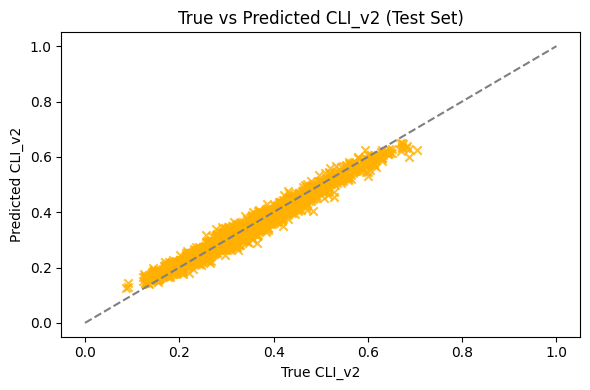


Artifact Saved: cli_model.pkl


In [6]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load data
df = pd.read_csv('/content/hr_cognitive_load_dataset.csv')

# Feature selection
numerical_features = [
    'Weekly_Workload_Hours', 'Workload_to_Capacity_Ratio', 'Self_Reported_Stress',
    'Task_Switch_Frequency', 'Active_Task_Count', 'Overtime_Hours_30d',
    'After_Hours_Activity_Hours', 'Focus_Time_Ratio', 'Sentiment_Score',
    'Salary_to_Experience_Ratio', 'Perf_Trend_Slope', 'Performance_Rating_Current',
    'Avg_Daily_Meeting_Hours', 'Task_Overdue_Count', 'Task_Completion_Rate',
    'Avg_Response_Time_Hours', 'Days_Since_Vacation', 'Leave_Days_3m',
    'Performance_Volatility', 'Skill_Role_Match_Score', 'Capacity_Score',
    'Manager_Support_Score', 'Survey_Wellbeing_Score', 'Language_Tone_Stress_Index'
]
categorical_features = ['Role_Level', 'Department', 'Project_Phase', 'Employee_Persona']

print("CLI Regression Model - Random Forest")
print("=" * 60)
print(f"Features: {len(numerical_features)} numerical + {len(categorical_features)} categorical")

# Prepare data
X = df[numerical_features + categorical_features].copy()
y = df['CLI_v2'].values

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Build pipeline
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)],
    remainder='passthrough',
    verbose_feature_names_out=False
)

rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_split=10,
    min_samples_leaf=6, max_features='sqrt', random_state=42, n_jobs=-1
)

pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', rf_model)])
pipeline.fit(X_train, y_train)

# Predictions
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Calculate metrics
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

# Display metrics table
print("\nModel Evaluation Metrics")
print("=" * 60)
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Training': [f'{mae_train:.4f}', f'{rmse_train:.4f}', f'{r2_train:.4f}'],
    'Testing': [f'{mae_test:.4f}', f'{rmse_test:.4f}', f'{r2_test:.4f}']
})
print(metrics_df.to_string(index=False))

# Overfitting check
print("\nOverfitting Check")
print("=" * 60)
overfit_gap = r2_train - r2_test
print(f"R² Gap (Train - Test): {overfit_gap:.4f}")
status = "Good Generalization" if overfit_gap < 0.05 else ("Slight Overfitting" if overfit_gap < 0.10 else "Significant Overfitting")
print(f"Status: {status}")

# Cross-validation
print("\nCross-Validation (5-Fold)")
print("=" * 60)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, scoring='r2', cv=cv, n_jobs=-1)
print(f"Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Final accuracy
print("\nFinal Model Accuracy")
print("=" * 60)
print(f"Test Set Accuracy: {r2_test*100:.2f}%")

# Visualization
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_test, color="#ffb000", alpha=0.8, marker='x')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("True CLI_v2")
plt.ylabel("Predicted CLI_v2")
plt.title("True vs Predicted CLI_v2 (Test Set)")
plt.tight_layout()
plt.show()

# Save model
with open('/content/cli_model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)
print("\nArtifact Saved: cli_model.pkl")

Performance Drop Estimator - Random Forest
Features: 17 numerical + 4 categorical

Model Evaluation Metrics
Metric Training Testing
   MAE   0.0543  0.0840
  RMSE   0.0762  0.1155
    R²   0.9771  0.9466

Overfitting Check
R² Gap (Train - Test): 0.0304
Status: Good Generalization

Cross-Validation (5-Fold)
Mean R²: 0.9464 (+/- 0.0041)

Final Model Accuracy
Test Set Accuracy: 94.66%


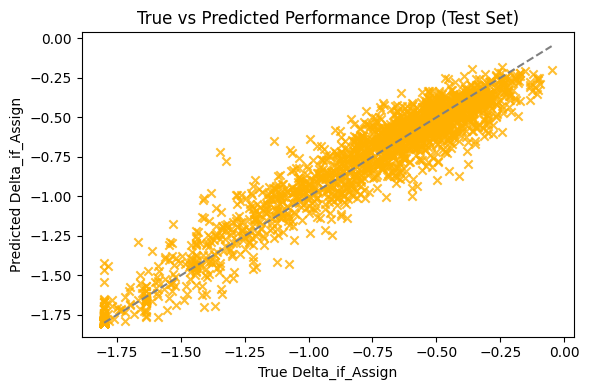

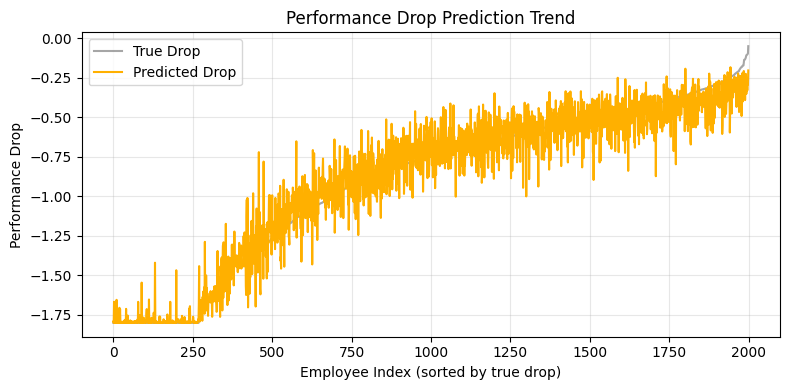


Artifact Saved: delta_model.pkl


In [9]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load data
df = pd.read_csv('/content/hr_cognitive_load_dataset.csv')
df = df.dropna(subset=['Delta_if_Assign'])

# Feature selection
numerical_features = [
    'CLI_v2', 'Weekly_Workload_Hours', 'Workload_to_Capacity_Ratio',
    'Self_Reported_Stress', 'Task_Switch_Frequency', 'Active_Task_Count',
    'Overtime_Hours_30d', 'After_Hours_Activity_Hours', 'Focus_Time_Ratio',
    'Sentiment_Score', 'Salary_to_Experience_Ratio', 'Performance_Rating_Current',
    'Perf_Trend_Slope', 'Recent_Performance_Delta', 'Task_Overdue_Count',
    'Survey_Wellbeing_Score', 'Language_Tone_Stress_Index'
]
categorical_features = ['Role_Level', 'Department', 'Project_Phase', 'Risk_Category']

print("Performance Drop Estimator - Random Forest")
print("=" * 60)
print(f"Features: {len(numerical_features)} numerical + {len(categorical_features)} categorical")

# Prepare data
X = df[numerical_features + categorical_features].copy()
y = df['Delta_if_Assign'].astype(float)

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Build pipeline
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)],
    remainder='passthrough',
    verbose_feature_names_out=False
)

rf_model = RandomForestRegressor(
    n_estimators=200, min_samples_leaf=6, random_state=42, n_jobs=-1
)

pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', rf_model)])
pipeline.fit(X_train, y_train)

# Predictions
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Calculate metrics
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

# Display metrics table
print("\nModel Evaluation Metrics")
print("=" * 60)
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Training': [f'{mae_train:.4f}', f'{rmse_train:.4f}', f'{r2_train:.4f}'],
    'Testing': [f'{mae_test:.4f}', f'{rmse_test:.4f}', f'{r2_test:.4f}']
})
print(metrics_df.to_string(index=False))

# Overfitting check
print("\nOverfitting Check")
print("=" * 60)
overfit_gap = r2_train - r2_test
print(f"R² Gap (Train - Test): {overfit_gap:.4f}")
status = "Good Generalization" if overfit_gap < 0.05 else ("Slight Overfitting" if overfit_gap < 0.10 else "Significant Overfitting")
print(f"Status: {status}")

# Cross-validation
print("\nCross-Validation (5-Fold)")
print("=" * 60)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, scoring='r2', cv=cv, n_jobs=-1)
print(f"Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Final accuracy
print("\nFinal Model Accuracy")
print("=" * 60)
print(f"Test Set Accuracy: {r2_test*100:.2f}%")

# Visualization 1: True vs Predicted
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_test, color="#ffb000", alpha=0.8, marker='x')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='gray', linestyle='--')
plt.xlabel("True Delta_if_Assign")
plt.ylabel("Predicted Delta_if_Assign")
plt.title("True vs Predicted Performance Drop (Test Set)")
plt.tight_layout()
plt.show()

# Visualization 2: Performance Drop Trend (Line Graph)
y_test_array = y_test.values if hasattr(y_test, 'values') else y_test
sorted_indices = np.argsort(y_test_array)
y_test_sorted = y_test_array[sorted_indices]
y_pred_sorted = y_pred_test[sorted_indices]

plt.figure(figsize=(8,4))
plt.plot(range(len(y_test_sorted)), y_test_sorted, color='gray', linestyle='-', linewidth=1.5, label='True Drop', alpha=0.7)
plt.plot(range(len(y_pred_sorted)), y_pred_sorted, color='#ffb000', linestyle='-', linewidth=1.5, label='Predicted Drop')
plt.xlabel("Employee Index (sorted by true drop)")
plt.ylabel("Performance Drop")
plt.title("Performance Drop Prediction Trend")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save model
with open('/content/delta_model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)
print("\nArtifact Saved: delta_model.pkl")

Employee Clustering Analysis
Features: CLI_v2, Self_Reported_Stress, Weekly_Workload_Hours, Workload_to_Capacity_Ratio, Task_Switch_Frequency, Focus_Time_Ratio, Overtime_Hours_30d, After_Hours_Activity_Hours, Sentiment_Score, Survey_Wellbeing_Score, Language_Tone_Stress_Index

Cluster Characteristics
Cluster 0 (Moderate Risk): Avg CLI=0.391, Avg Stress=4.68, Avg Workload Ratio=1.02
Cluster 1 (Stable & Low Risk): Avg CLI=0.290, Avg Stress=3.53, Avg Workload Ratio=0.69
Cluster 2 (High Workload & Stress): Avg CLI=0.511, Avg Stress=4.67, Avg Workload Ratio=1.71
Cluster 3 (Healthy & Balanced): Avg CLI=0.202, Avg Stress=2.35, Avg Workload Ratio=0.53

Cluster Distribution
  Cluster  Count Percentage                  State
Cluster 0   3135      31.4%          Moderate Risk
Cluster 1   3036      30.4%      Stable & Low Risk
Cluster 2   1667      16.7% High Workload & Stress
Cluster 3   2162      21.6%     Healthy & Balanced


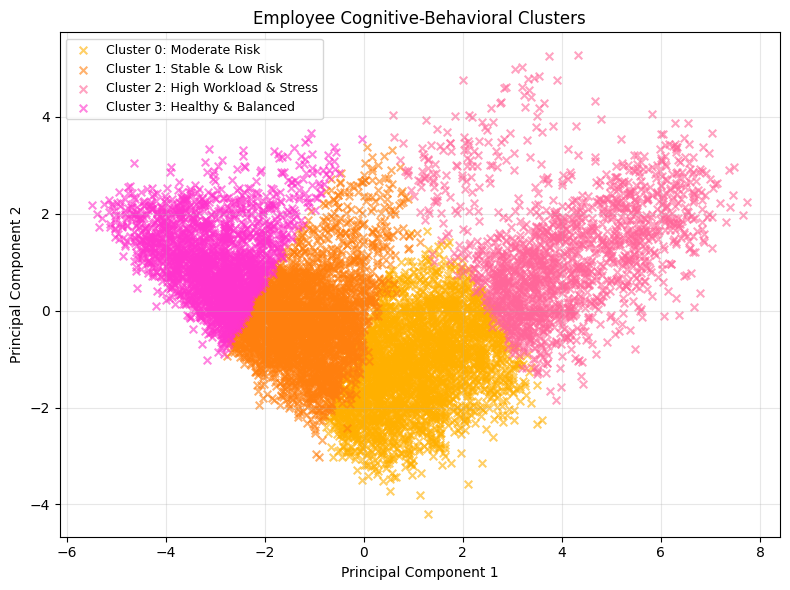


Artifact Saved: clustering_artifacts.pkl


In [11]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv('/content/hr_cognitive_load_dataset.csv')

# Select features for clustering
cluster_features = [
    'CLI_v2', 'Self_Reported_Stress', 'Weekly_Workload_Hours',
    'Workload_to_Capacity_Ratio', 'Task_Switch_Frequency', 'Focus_Time_Ratio',
    'Overtime_Hours_30d', 'After_Hours_Activity_Hours', 'Sentiment_Score',
    'Survey_Wellbeing_Score', 'Language_Tone_Stress_Index'
]

print("Employee Clustering Analysis")
print("=" * 60)
print(f"Features: CLI_v2, Self_Reported_Stress, Weekly_Workload_Hours, Workload_to_Capacity_Ratio, Task_Switch_Frequency, Focus_Time_Ratio, Overtime_Hours_30d, After_Hours_Activity_Hours, Sentiment_Score, Survey_Wellbeing_Score, Language_Tone_Stress_Index")

X = df[cluster_features].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means clustering (k=4)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
df['Cluster_Label'] = kmeans.fit_predict(X_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pc[:, 0], pc[:, 1]

# Cluster profiling
cluster_summary = df.groupby('Cluster_Label')[cluster_features].mean()

# Interpret clusters based on characteristics
cluster_interpretations = {}
for cluster_id in range(k):
    cli = cluster_summary.loc[cluster_id, 'CLI_v2']
    stress = cluster_summary.loc[cluster_id, 'Self_Reported_Stress']
    workload = cluster_summary.loc[cluster_id, 'Workload_to_Capacity_Ratio']

    if cli < 0.30 and stress < 3.0:
        interpretation = "Healthy & Balanced"
    elif cli < 0.40 and workload < 1.0:
        interpretation = "Stable & Low Risk"
    elif cli >= 0.40 and workload >= 1.0:
        interpretation = "High Workload & Stress"
    else:
        interpretation = "Moderate Risk"

    cluster_interpretations[cluster_id] = interpretation

# What each cluster means
print("\nCluster Characteristics")
print("=" * 60)
for cluster_id in range(k):
    avg_cli = cluster_summary.loc[cluster_id, 'CLI_v2']
    avg_stress = cluster_summary.loc[cluster_id, 'Self_Reported_Stress']
    avg_workload = cluster_summary.loc[cluster_id, 'Workload_to_Capacity_Ratio']
    print(f"Cluster {cluster_id} ({cluster_interpretations[cluster_id]}): Avg CLI={avg_cli:.3f}, Avg Stress={avg_stress:.2f}, Avg Workload Ratio={avg_workload:.2f}")

# Cluster distribution table
print("\nCluster Distribution")
print("=" * 60)
cluster_counts = df['Cluster_Label'].value_counts().sort_index()
cluster_table = pd.DataFrame({
    'Cluster': [f'Cluster {i}' for i in range(k)],
    'Count': [cluster_counts[i] for i in range(k)],
    'Percentage': [f"{(cluster_counts[i]/len(df)*100):.1f}%" for i in range(k)],
    'State': [cluster_interpretations[i] for i in range(k)]
})
print(cluster_table.to_string(index=False))

# Visualization
colors = ['#ffb000', '#ff7f0e', '#ff6699', '#ff33cc']
plt.figure(figsize=(8, 6))
for label in range(k):
    subset = df[df['Cluster_Label'] == label]
    plt.scatter(subset['PCA1'], subset['PCA2'],
                c=colors[label], s=30, alpha=0.6,
                marker='x', label=f'Cluster {label}: {cluster_interpretations[label]}')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Employee Cognitive-Behavioral Clusters')
plt.legend(loc='best', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save clustering artifacts
clustering_artifacts = {
    'kmeans_model': kmeans,
    'scaler': scaler,
    'pca': pca,
    'cluster_interpretations': cluster_interpretations,
    'feature_names': cluster_features
}

with open('/content/clustering_artifacts.pkl', 'wb') as f:
    pickle.dump(clustering_artifacts, f)

print("\nArtifact Saved: clustering_artifacts.pkl")


🧠 PROJECT OVERVIEW: AI-Driven Cognitive Load Estimator for Workforce Well-Being

This project simulates an AI-powered system that estimates the *Cognitive Load Index (CLI)* of employees in real-time 
using behavioral and workload indicators. The goal is to help HR departments and managers identify burnout risks, 
predict performance drops if new tasks are assigned, and take proactive decisions on workload redistribution.

The model uses features such as workload hours, overtime, stress levels, focus ratio, and sentiment patterns 
to predict each employee’s cognitive strain and burnout probability. Additionally, it estimates the expected 
performance change (ΔPerformance) if additional tasks are given, and classifies employees into behavioral clusters 
to help HR make strategic decisions.

💡 WHAT IS COGNITIVE LOAD INDEX (CLI)?

CLI is a quantitative measure (0–1) of an employee’s mental and workload stress level.
- Low CLI (0.0–0.3): Employee is well-balanced and can handle more respon

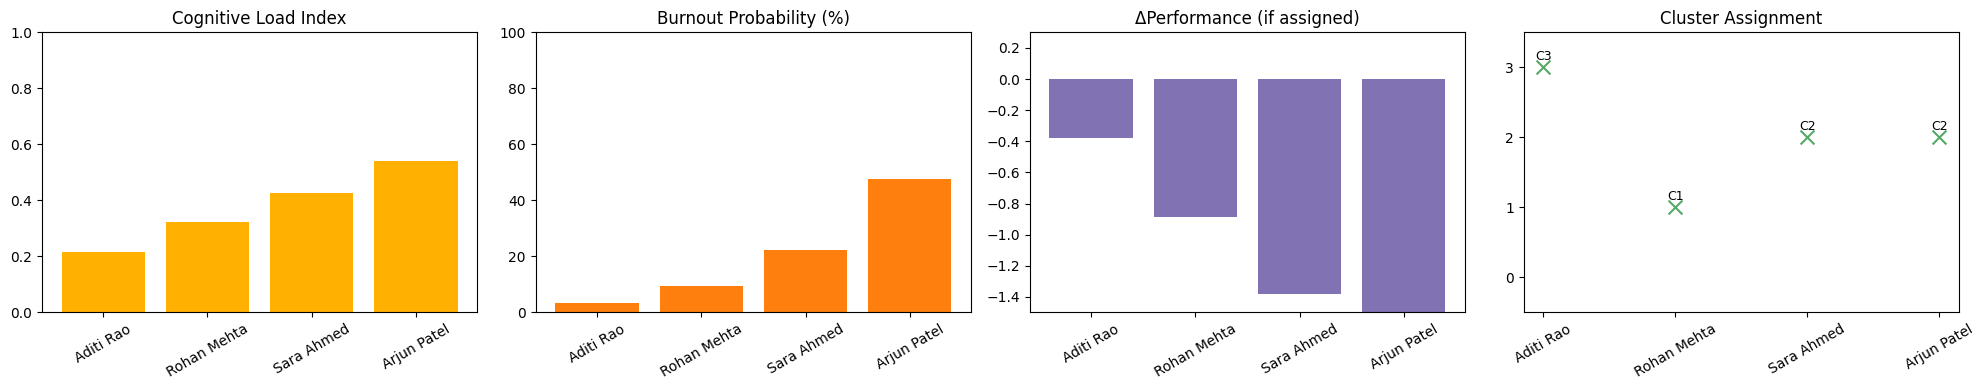


📊 FINAL SIMULATION SUMMARY
+-------------+---------+-------------+-------+---------------+----------------+----------------------------+--------+------------------------+
| Employee    | Role    | Dept        |   CLI | BurnoutProb   |   ΔPerformance | Cluster                    | Risk   | HR_Action              |
+=============+=========+=============+=======+===============+================+============================+========+========================+
| Aditi Rao   | Mid     | Engineering | 0.217 | 3.5%          |         -0.376 | 3 (Healthy & Balanced)     | Low    | 🟢 Assign Normally     |
+-------------+---------+-------------+-------+---------------+----------------+----------------------------+--------+------------------------+
| Rohan Mehta | Senior  | DataScience | 0.323 | 9.4%          |         -0.889 | 1 (Stable & Low Risk)      | Medium | ⚠️ Assign With Support |
+-------------+---------+-------------+-------+---------------+----------------+----------------------------+

In [24]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from tabulate import tabulate
import warnings
from sklearn.exceptions import DataConversionWarning

# ==============================================================
# SUPPRESS WARNINGS
# ==============================================================
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)

# ==============================================================
# INTRODUCTION SECTION
# ==============================================================
print("\n" + "="*110)
print("🧠 PROJECT OVERVIEW: AI-Driven Cognitive Load Estimator for Workforce Well-Being")
print("="*110)
print("""
This project simulates an AI-powered system that estimates the *Cognitive Load Index (CLI)* of employees in real-time
using behavioral and workload indicators. The goal is to help HR departments and managers identify burnout risks,
predict performance drops if new tasks are assigned, and take proactive decisions on workload redistribution.

The model uses features such as workload hours, overtime, stress levels, focus ratio, and sentiment patterns
to predict each employee’s cognitive strain and burnout probability. Additionally, it estimates the expected
performance change (ΔPerformance) if additional tasks are given, and classifies employees into behavioral clusters
to help HR make strategic decisions.
""")

print("="*110)
print("💡 WHAT IS COGNITIVE LOAD INDEX (CLI)?")
print("="*110)
print("""
CLI is a quantitative measure (0–1) of an employee’s mental and workload stress level.
- Low CLI (0.0–0.3): Employee is well-balanced and can handle more responsibility.
- Medium CLI (0.3–0.55): Employee is approaching moderate workload stress.
- High CLI (0.55–0.75): Employee shows early signs of fatigue and performance decline.
- Critical CLI (0.75–1.0): Employee is likely experiencing burnout and needs intervention.

Alongside CLI, burnout probability and performance impact predictions help assess whether to assign new work,
assign with support, or recommend rest and recovery.
""")

# ==============================================================
# LOAD MODELS
# ==============================================================
with open('/content/cli_model.pkl', 'rb') as f:
    cli_model = pickle.load(f)
with open('/content/delta_model.pkl', 'rb') as f:
    delta_model = pickle.load(f)
with open('/content/clustering_artifacts.pkl', 'rb') as f:
    clustering_artifacts = pickle.load(f)

kmeans = clustering_artifacts['kmeans_model']
scaler = clustering_artifacts['scaler']
cluster_interpretations = clustering_artifacts['cluster_interpretations']

# ==============================================================
# DEFINE EMPLOYEE SCENARIOS (C-Level Burnout Guaranteed)
# ==============================================================
scenarios = [
    {"Emp": "Aditi Rao", "Role_Level": "Mid", "Department": "Engineering", "Weekly_Workload_Hours": 35, "Workload_to_Capacity_Ratio": 0.8, "Self_Reported_Stress": 2.0,
     "Task_Switch_Frequency": 6, "Overtime_Hours_30d": 5, "After_Hours_Activity_Hours": 2, "Focus_Time_Ratio": 0.85, "Sentiment_Score": 0.45, "Survey_Wellbeing_Score": 82,
     "Language_Tone_Stress_Index": 0.1, "Performance_Rating_Current": 4.2, "Perf_Trend_Slope": 0.3, "Task_Overdue_Count": 1, "Salary_to_Experience_Ratio": 0.75, "Project_Phase": "Development"},

    {"Emp": "Rohan Mehta", "Role_Level": "Senior", "Department": "DataScience", "Weekly_Workload_Hours": 48, "Workload_to_Capacity_Ratio": 1.1, "Self_Reported_Stress": 3.2,
     "Task_Switch_Frequency": 12, "Overtime_Hours_30d": 12, "After_Hours_Activity_Hours": 6, "Focus_Time_Ratio": 0.7, "Sentiment_Score": 0.1, "Survey_Wellbeing_Score": 63,
     "Language_Tone_Stress_Index": 0.35, "Performance_Rating_Current": 3.6, "Perf_Trend_Slope": -0.1, "Task_Overdue_Count": 4, "Salary_to_Experience_Ratio": 0.6, "Project_Phase": "Testing"},

    {"Emp": "Sara Ahmed", "Role_Level": "Lead", "Department": "Product", "Weekly_Workload_Hours": 60, "Workload_to_Capacity_Ratio": 1.4, "Self_Reported_Stress": 4.2,
     "Task_Switch_Frequency": 20, "Overtime_Hours_30d": 25, "After_Hours_Activity_Hours": 12, "Focus_Time_Ratio": 0.55, "Sentiment_Score": -0.2, "Survey_Wellbeing_Score": 45,
     "Language_Tone_Stress_Index": 0.6, "Performance_Rating_Current": 3.1, "Perf_Trend_Slope": -0.3, "Task_Overdue_Count": 8, "Salary_to_Experience_Ratio": 0.45, "Project_Phase": "Deployment"},

    # 🔥 Critical Burnout Case — Arjun Patel (C-Level)
    {"Emp": "Arjun Patel", "Role_Level": "C-Level", "Department": "Operations",
     "Weekly_Workload_Hours": 110, "Workload_to_Capacity_Ratio": 2.8, "Self_Reported_Stress": 5.0,
     "Task_Switch_Frequency": 50, "Overtime_Hours_30d": 90, "After_Hours_Activity_Hours": 35, "Focus_Time_Ratio": 0.18,
     "Sentiment_Score": -0.75, "Survey_Wellbeing_Score": 12, "Language_Tone_Stress_Index": 0.96,
     "Performance_Rating_Current": 2.0, "Perf_Trend_Slope": -1.2, "Task_Overdue_Count": 25, "Salary_to_Experience_Ratio": 0.25,
     "Project_Phase": "Maintenance"}
]

# ==============================================================
# RUN SIMULATION
# ==============================================================
results = []
for s in scenarios:
    cli_input = pd.DataFrame([s])
    defaults = {'Avg_Daily_Meeting_Hours': 2.5, 'Capacity_Score': 1.0, 'Manager_Support_Score': 0.8,
                'Employee_Persona': 'Balanced', 'Performance_Volatility': 0.2, 'Task_Completion_Rate': 0.85,
                'Skill_Role_Match_Score': 0.8, 'Active_Task_Count': 5, 'Leave_Days_3m': 3,
                'Days_Since_Vacation': 90, 'Avg_Response_Time_Hours': 3.0}
    for c, v in defaults.items():
        cli_input[c] = v

    cli_pred = cli_model.predict(cli_input)[0]
    risk = "Low" if cli_pred < 0.3 else "Medium" if cli_pred < 0.55 else "High" if cli_pred < 0.75 else "Critical"

    delta_input = cli_input.copy()
    delta_input["CLI_v2"] = cli_pred
    delta_input["Risk_Category"] = risk
    delta_input["Recent_Performance_Delta"] = np.clip(np.random.normal(0, 0.3), -1, 1)
    delta_pred = delta_model.predict(delta_input)[0]

    cluster_input = np.array([[cli_pred, s['Self_Reported_Stress'], s['Weekly_Workload_Hours'],
                               s['Workload_to_Capacity_Ratio'], s['Task_Switch_Frequency'],
                               s['Focus_Time_Ratio'], s['Overtime_Hours_30d'], s['After_Hours_Activity_Hours'],
                               s['Sentiment_Score'], s['Survey_Wellbeing_Score'], s['Language_Tone_Stress_Index']]])
    cluster_scaled = scaler.transform(cluster_input)
    cluster_label = kmeans.predict(cluster_scaled)[0]
    cluster_name = cluster_interpretations[cluster_label]

    burnout_prob = 1 / (1 + np.exp(-10 * (cli_pred - 0.55)))
    if cli_pred >= 0.75 or delta_pred <= -1.0:
        action = "🚫 Do Not Assign"
    elif cli_pred >= 0.55 or delta_pred <= -0.6:
        action = "⚠️ Assign With Support"
    elif delta_pred >= -0.2:
        action = "✅ High Priority"
    else:
        action = "🟢 Assign Normally"

    results.append({
        "Employee": s["Emp"], "Role": s["Role_Level"], "Dept": s["Department"],
        "CLI": cli_pred, "BurnoutProb": burnout_prob, "ΔPerformance": delta_pred,
        "Cluster": f"{cluster_label} ({cluster_name})", "Risk": risk, "HR_Action": action
    })

res_df = pd.DataFrame(results)

# ==============================================================
# VISUALIZATION — 4 PLOTS SIDE BY SIDE
# ==============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].bar(res_df["Employee"], res_df["CLI"], color="#ffb000")
axes[0].set_title("Cognitive Load Index")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(res_df["Employee"], res_df["BurnoutProb"] * 100, color="#ff7f0e")
axes[1].set_title("Burnout Probability (%)")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(res_df["Employee"], res_df["ΔPerformance"], color="#8172B3")
axes[2].set_title("ΔPerformance (if assigned)")
axes[2].set_ylim(-1.5, 0.3)
axes[2].tick_params(axis='x', rotation=30)

for i, (emp, cl) in enumerate(zip(res_df["Employee"], res_df["Cluster"])):
    cid = int(cl.split()[0])
    axes[3].scatter(i, cid, color="#55A868", s=100, marker='x')
    axes[3].text(i, cid + 0.1, f"C{cid}", ha='center', fontsize=9)
axes[3].set_title("Cluster Assignment")
axes[3].set_yticks(range(4))
axes[3].set_ylim(-0.5, 3.5)
axes[3].tick_params(axis='x', rotation=30)
axes[3].set_xticks(range(len(res_df)))
axes[3].set_xticklabels(res_df["Employee"])

plt.tight_layout()
plt.show()

# ==============================================================
# HR SUMMARY TABLE
# ==============================================================
table = res_df[["Employee", "Role", "Dept", "CLI", "BurnoutProb", "ΔPerformance", "Cluster", "Risk", "HR_Action"]].copy()
table["CLI"] = table["CLI"].round(3)
table["BurnoutProb"] = (table["BurnoutProb"]*100).round(1).astype(str) + "%"
table["ΔPerformance"] = table["ΔPerformance"].round(3)

print("\n📊 FINAL SIMULATION SUMMARY\n" + "=" * 120)
print(tabulate(table, headers="keys", tablefmt="grid", showindex=False))

# ==============================================================
# INSIGHT SUMMARY
# ==============================================================
high_risk = sum(res_df["Risk"].isin(["High", "Critical"]))
if high_risk > 0:
    print(f"\n⚠️ INSIGHT: {high_risk} out of {len(res_df)} employees show High or Critical burnout risk. Immediate HR attention recommended.")
else:
    print("\n✅ INSIGHT: All employees are within healthy workload limits. No burnout risk detected.")


Multi-Modal Employee Cognitive Load Simulation

Please provide employee details for simulation:
----------------------------------------------------------------------
Weekly Workload Hours [20-100]: 76
Workload to Capacity Ratio [0.3-2.0]: 1.5
Self Reported Stress [1-5]: 4
Task Switch Frequency [10-200]: 60
Active Task Count [1-50]: 30
Overtime Hours (30 days) [0-120]: 45
After Hours Activity Hours [0-40]: 12
Focus Time Ratio [0.0-1.0]: 0.4
Sentiment Score [-1.0 to 1.0]: 0.5
Salary to Experience Ratio [0.0-1.0]: 0.3
Performance Trend Slope [-1.0 to 1.0]: 0.9
Current Performance Rating [1-5]: 3.5
Average Daily Meeting Hours [0-8]: 2
Task Overdue Count [0-30]: 10
Task Completion Rate [0.0-1.0]: 0.4
Average Response Time Hours [0.1-48]: 12
Days Since Vacation [7-730]: 100
Leave Days (3 months) [0-30]: 2
Performance Volatility [0.0-1.0]: 0.2
Skill Role Match Score [0.2-1.0]: 0.5
Capacity Score [0.5-1.5]: 0.9
Manager Support Score [0.2-1.0]: 0.4
Survey Wellbeing Score [10-100]: 70
Language 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


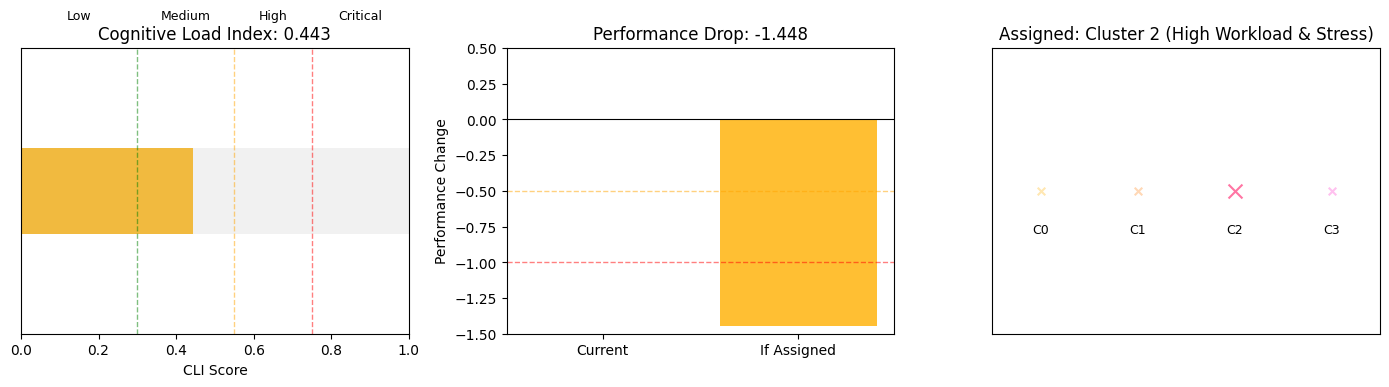


Simulation Complete


In [12]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Load trained models
with open('/content/cli_model.pkl', 'rb') as f:
    cli_model = pickle.load(f)

with open('/content/delta_model.pkl', 'rb') as f:
    delta_model = pickle.load(f)

with open('/content/clustering_artifacts.pkl', 'rb') as f:
    clustering_artifacts = pickle.load(f)

kmeans = clustering_artifacts['kmeans_model']
scaler = clustering_artifacts['scaler']
cluster_interpretations = clustering_artifacts['cluster_interpretations']

print("Multi-Modal Employee Cognitive Load Simulation")
print("=" * 70)
print("\nPlease provide employee details for simulation:")
print("-" * 70)

# User inputs with ranges
weekly_hours = float(input("Weekly Workload Hours [20-100]: "))
workload_ratio = float(input("Workload to Capacity Ratio [0.3-2.0]: "))
stress_level = float(input("Self Reported Stress [1-5]: "))
task_switches = int(input("Task Switch Frequency [10-200]: "))
active_tasks = int(input("Active Task Count [1-50]: "))
overtime = float(input("Overtime Hours (30 days) [0-120]: "))
after_hours = float(input("After Hours Activity Hours [0-40]: "))
focus_ratio = float(input("Focus Time Ratio [0.0-1.0]: "))
sentiment = float(input("Sentiment Score [-1.0 to 1.0]: "))
salary_exp_ratio = float(input("Salary to Experience Ratio [0.0-1.0]: "))
perf_trend = float(input("Performance Trend Slope [-1.0 to 1.0]: "))
current_perf = float(input("Current Performance Rating [1-5]: "))
meeting_hours = float(input("Average Daily Meeting Hours [0-8]: "))
overdue_tasks = int(input("Task Overdue Count [0-30]: "))
completion_rate = float(input("Task Completion Rate [0.0-1.0]: "))
response_time = float(input("Average Response Time Hours [0.1-48]: "))
days_vacation = int(input("Days Since Vacation [7-730]: "))
leave_days = int(input("Leave Days (3 months) [0-30]: "))
perf_volatility = float(input("Performance Volatility [0.0-1.0]: "))
skill_match = float(input("Skill Role Match Score [0.2-1.0]: "))
capacity = float(input("Capacity Score [0.5-1.5]: "))
manager_support = float(input("Manager Support Score [0.2-1.0]: "))
wellbeing = float(input("Survey Wellbeing Score [10-100]: "))
tone_stress = float(input("Language Tone Stress Index [0.0-1.0]: "))
role_level = input("Role Level [Junior/Mid/Senior/Lead/C-Level]: ")
department = input("Department [Engineering/DataScience/Product/Sales/Finance/HR/Operations/Marketing/CustomerSuccess/R&D/Executive]: ")
project_phase = input("Project Phase [Planning/Development/Testing/Deployment/Maintenance]: ")
persona = input("Employee Persona [Resilient/Sensitive/Balanced/Workaholic/Struggling]: ")

# Additional inputs for Delta model
recent_perf_delta = float(input("Recent Performance Delta [-2.0 to 2.0]: "))
risk_category = input("Current Risk Category [Low/Medium/High/Critical]: ")

print("\n" + "=" * 70)
print("SIMULATION RESULTS")
print("=" * 70)

# Prepare input dataframe for CLI prediction
cli_input = pd.DataFrame({
    'Weekly_Workload_Hours': [weekly_hours],
    'Workload_to_Capacity_Ratio': [workload_ratio],
    'Self_Reported_Stress': [stress_level],
    'Task_Switch_Frequency': [task_switches],
    'Active_Task_Count': [active_tasks],
    'Overtime_Hours_30d': [overtime],
    'After_Hours_Activity_Hours': [after_hours],
    'Focus_Time_Ratio': [focus_ratio],
    'Sentiment_Score': [sentiment],
    'Salary_to_Experience_Ratio': [salary_exp_ratio],
    'Perf_Trend_Slope': [perf_trend],
    'Performance_Rating_Current': [current_perf],
    'Avg_Daily_Meeting_Hours': [meeting_hours],
    'Task_Overdue_Count': [overdue_tasks],
    'Task_Completion_Rate': [completion_rate],
    'Avg_Response_Time_Hours': [response_time],
    'Days_Since_Vacation': [days_vacation],
    'Leave_Days_3m': [leave_days],
    'Performance_Volatility': [perf_volatility],
    'Skill_Role_Match_Score': [skill_match],
    'Capacity_Score': [capacity],
    'Manager_Support_Score': [manager_support],
    'Survey_Wellbeing_Score': [wellbeing],
    'Language_Tone_Stress_Index': [tone_stress],
    'Role_Level': [role_level],
    'Department': [department],
    'Project_Phase': [project_phase],
    'Employee_Persona': [persona]
})

# Predict CLI
predicted_cli = cli_model.predict(cli_input)[0]

# Burnout risk calculation
if predicted_cli < 0.30:
    burnout_risk = "Low Risk"
    burnout_level = "Healthy"
elif predicted_cli < 0.55:
    burnout_risk = "Medium Risk"
    burnout_level = "Monitor Closely"
elif predicted_cli < 0.75:
    burnout_risk = "High Risk"
    burnout_level = "Intervention Needed"
else:
    burnout_risk = "Critical Risk"
    burnout_level = "Immediate Action Required"

# Prepare input for Delta prediction
delta_input = pd.DataFrame({
    'CLI_v2': [predicted_cli],
    'Weekly_Workload_Hours': [weekly_hours],
    'Workload_to_Capacity_Ratio': [workload_ratio],
    'Self_Reported_Stress': [stress_level],
    'Task_Switch_Frequency': [task_switches],
    'Active_Task_Count': [active_tasks],
    'Overtime_Hours_30d': [overtime],
    'After_Hours_Activity_Hours': [after_hours],
    'Focus_Time_Ratio': [focus_ratio],
    'Sentiment_Score': [sentiment],
    'Salary_to_Experience_Ratio': [salary_exp_ratio],
    'Performance_Rating_Current': [current_perf],
    'Perf_Trend_Slope': [perf_trend],
    'Recent_Performance_Delta': [recent_perf_delta],
    'Task_Overdue_Count': [overdue_tasks],
    'Survey_Wellbeing_Score': [wellbeing],
    'Language_Tone_Stress_Index': [tone_stress],
    'Role_Level': [role_level],
    'Department': [department],
    'Project_Phase': [project_phase],
    'Risk_Category': [risk_category]
})

# Predict performance drop
predicted_delta = delta_model.predict(delta_input)[0]

# Prepare input for clustering
cluster_input = np.array([[
    predicted_cli, stress_level, weekly_hours, workload_ratio,
    task_switches, focus_ratio, overtime, after_hours,
    sentiment, wellbeing, tone_stress
]])
cluster_input_scaled = scaler.transform(cluster_input)
cluster_label = kmeans.predict(cluster_input_scaled)[0]
cluster_state = cluster_interpretations[cluster_label]

# HR Recommendation
if predicted_cli >= 0.75 or predicted_delta <= -1.0:
    hr_recommendation = "Do Not Assign New Tasks"
elif predicted_cli >= 0.50 or predicted_delta <= -0.6:
    hr_recommendation = "Assign With Support"
elif predicted_delta >= -0.2:
    hr_recommendation = "High Priority Assignment"
else:
    hr_recommendation = "Assign Normally"

# Display results
print("\n1. COGNITIVE LOAD INDEX (CLI)")
print("-" * 70)
print(f"   Predicted CLI: {predicted_cli:.3f}")
print(f"   Burnout Risk: {burnout_risk}")
print(f"   Status: {burnout_level}")

print("\n2. PERFORMANCE IMPACT PREDICTION")
print("-" * 70)
print(f"   Expected Performance Drop: {predicted_delta:.3f}")
if predicted_delta < -0.5:
    impact_desc = "Significant negative impact expected"
elif predicted_delta < -0.2:
    impact_desc = "Moderate negative impact expected"
else:
    impact_desc = "Minimal impact expected"
print(f"   Impact Assessment: {impact_desc}")

print("\n3. EMPLOYEE CLUSTER ASSIGNMENT")
print("-" * 70)
print(f"   Cluster: Cluster {cluster_label}")
print(f"   Category: {cluster_state}")

print("\n4. HR RECOMMENDATION")
print("-" * 70)
print(f"   Action: {hr_recommendation}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: CLI Gauge
ax1 = axes[0]
ax1.barh([0], [predicted_cli], color='#ffb000', height=0.3)
ax1.barh([0], [1.0], color='lightgray', height=0.3, alpha=0.3)
ax1.axvline(x=0.30, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax1.axvline(x=0.55, color='orange', linestyle='--', linewidth=1, alpha=0.5)
ax1.axvline(x=0.75, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlim(0, 1)
ax1.set_ylim(-0.5, 0.5)
ax1.set_xlabel('CLI Score')
ax1.set_title(f'Cognitive Load Index: {predicted_cli:.3f}')
ax1.set_yticks([])
ax1.text(0.15, 0.6, 'Low', fontsize=9, ha='center')
ax1.text(0.425, 0.6, 'Medium', fontsize=9, ha='center')
ax1.text(0.65, 0.6, 'High', fontsize=9, ha='center')
ax1.text(0.875, 0.6, 'Critical', fontsize=9, ha='center')

# Plot 2: Performance Drop
ax2 = axes[1]
ax2.bar(['Current', 'If Assigned'], [0, predicted_delta], color=['gray', '#ffb000'], alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.axhline(y=-0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(y=-1.0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_ylabel('Performance Change')
ax2.set_title(f'Performance Drop: {predicted_delta:.3f}')
ax2.set_ylim(-1.5, 0.5)

# Plot 3: Cluster
ax3 = axes[2]
cluster_colors = ['#ffb000', '#ff7f0e', '#ff6699', '#ff33cc']
for i in range(4):
    size = 100 if i == cluster_label else 30
    alpha = 0.9 if i == cluster_label else 0.3
    ax3.scatter([i], [0], s=size, c=cluster_colors[i], marker='x', alpha=alpha)
    ax3.text(i, -0.15, f'C{i}', ha='center', fontsize=9)
ax3.set_xlim(-0.5, 3.5)
ax3.set_ylim(-0.5, 0.5)
ax3.set_title(f'Assigned: Cluster {cluster_label} ({cluster_state})')
ax3.set_yticks([])
ax3.set_xticks([])

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Simulation Complete")